# 04 — Avaliação no Conjunto de Teste

Carrega o melhor checkpoint salvo durante o treino e avalia o modelo
nas imagens de teste — imagens que o modelo **nunca viu** durante treino ou validação.

Gera:
- Métricas quantitativas: Dice, Jaccard, Accuracy, Precision, Recall, Specificity
- Visualização qualitativa: pares imagem / ground truth / predição
- CSVs e figuras salvos em `results/`


## 1. Imports e Configuração


In [1]:
import sys
import os
from pathlib import Path

# Muda para a raiz do projeto (2 níveis acima do notebook)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent.parent
os.chdir(project_root)

sys.path.insert(0, str(project_root / 'skin_lesion'))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim

from src.models.unet import UNet
from src.models.dataset import SkinLesionDataset
from src.utils import load_checkpoint

with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

tcfg   = cfg['training']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


Device: cuda


## 2. Carregar Modelo e Checkpoint


In [2]:
model = UNet(
    in_channels=tcfg['in_channels'],
    out_channels=tcfg['out_channels'],
    features=tcfg['features'],
).to(DEVICE)

ckpt_dir  = Path(tcfg['checkpoint_dir'])
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / 'unet_5blocks.pth'

state = {}

if ckpt_path.exists():
    state = load_checkpoint(ckpt_path, model)
else:
    print(f"Checkpoint não encontrado em {ckpt_path}.")

print(f"Checkpoint da época : {state.get('epoch')}")
print(f"Dice de validação   : {state.get('val_dice', 'N/A'):.4f}")

model.eval()


=> Carregando checkpoint: skin_lesion\results\checkpoints\unet_5blocks.pth
Checkpoint da época : 16
Dice de validação   : 0.8957


UNet(
  (downs): ModuleList(
    (0): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_run

## 3. Dataset e DataLoader de Teste


In [3]:
h = cfg['preprocessing']['resize']['height']
w = cfg['preprocessing']['resize']['width']

# Sem augmentation — só normalização, igual ao val_transform do treino
test_transform = A.Compose([
    A.Resize(height=h, width=w),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])

test_ds = SkinLesionDataset(
    image_dir=tcfg['test_image_dir'],
    mask_dir=tcfg['test_mask_dir'],
    transform=test_transform,
)
test_loader = DataLoader(
    test_ds,
    batch_size=tcfg['batch_size'],
    shuffle=False,
    num_workers=tcfg['num_workers'],
    pin_memory=tcfg['pin_memory'],
)
print(f'Teste: {len(test_ds)} imagens | {len(test_loader)} batches')


Teste: 1000 imagens | 125 batches


## 4. Métricas Quantitativas


In [5]:
def evaluate_test(loader, model, device):
    """
    Avalia o modelo no loader de teste.
    Retorna Dice, Jaccard, Accuracy, Precision, Recall e Specificity por imagem
    e as médias gerais.
    """
    rows = []
    model.eval()

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(tqdm(loader, desc='Avaliando')):
            images = images.to(device)
            masks  = masks.unsqueeze(1).to(device)   # (B,H,W) → (B,1,H,W)

            preds_prob = torch.sigmoid(model(images))     # probabilidades [0,1]
            preds_bin  = (preds_prob > 0.5).float()       # binariza com threshold 0.5

            # Métricas por imagem no batch
            for i in range(images.shape[0]):
                p = preds_bin[i, 0]   # (H, W)
                g = masks[i, 0]       # (H, W)

                tp = (p * g).sum().item()
                fp = (p * (1 - g)).sum().item()
                fn = ((1 - p) * g).sum().item()
                tn = ((1 - p) * (1 - g)).sum().item()

                dice        = (2 * tp) / (2 * tp + fp + fn + 1e-8)
                jaccard     = tp / (tp + fp + fn + 1e-8)
                accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-8)
                precision   = tp / (tp + fp + 1e-8)
                recall      = tp / (tp + fn + 1e-8)      # Sensitivity
                specificity = tn / (tn + fp + 1e-8)

                rows.append({
                    'image_idx':   batch_idx * loader.batch_size + i,
                    'dice':        round(dice,        4),
                    'jaccard':     round(jaccard,     4),
                    'accuracy':    round(accuracy,    4),
                    'precision':   round(precision,   4),
                    'recall':      round(recall,      4),
                    'specificity': round(specificity, 4),
                })

    return pd.DataFrame(rows)


df_test = evaluate_test(test_loader, model, DEVICE)

# Salva resultado por imagem
df_test.to_csv('skin_lesion/results/metrics/test_results_5blocks.csv', index=False)

# Resumo geral
summary = df_test.drop(columns='image_idx').agg(['mean', 'std']).round(4)
summary.to_csv('skin_lesion/results/metrics/test_5blocks.csv')

print('\nResultados no conjunto de teste:')
display(summary)


Avaliando: 100%|██████████| 125/125 [00:28<00:00,  4.40it/s]


Resultados no conjunto de teste:


,dice,jaccard,accuracy,precision,recall,specificity
mean,0.8704,0.7936,0.9280,0.8864,0.8981,0.9639
std,0.1483,0.1786,0.1217,0.1145,0.1943,0.0530


## 5. Visualização Qualitativa

Exibe pares aleatórios: imagem pré-processada | ground truth | predição.


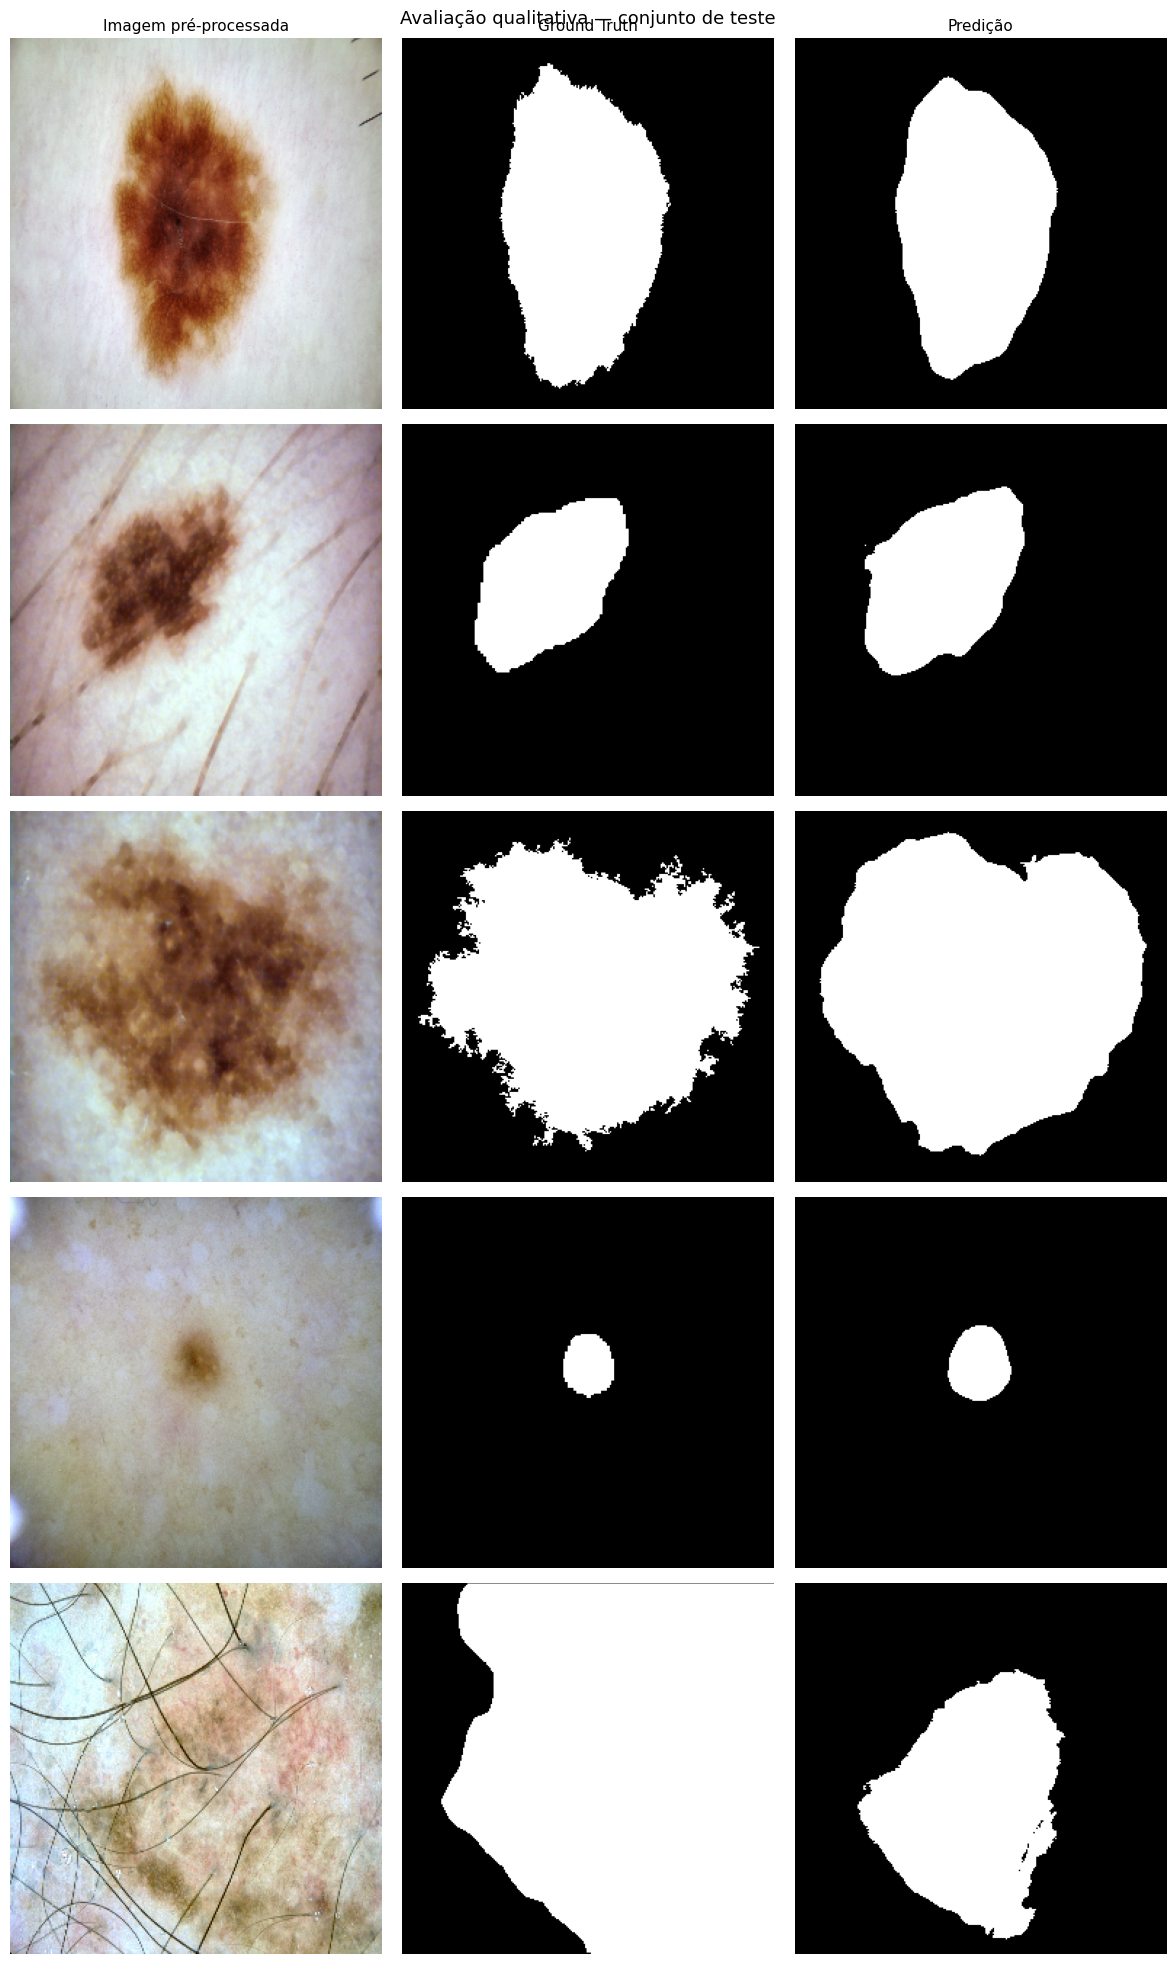

In [6]:
import random

N_SAMPLES = 5  # quantos exemplos exibir

# Coleta N amostras aleatórias do loader
all_images, all_masks, all_preds = [], [], []

model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        preds = (torch.sigmoid(model(images.to(DEVICE))) > 0.5).float().cpu()
        all_images.append(images)
        all_masks.append(masks)
        all_preds.append(preds)

all_images = torch.cat(all_images)
all_masks  = torch.cat(all_masks)
all_preds  = torch.cat(all_preds)

indices = random.sample(range(len(all_images)), N_SAMPLES)

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
fig.suptitle('Avaliação qualitativa — conjunto de teste', fontsize=13)

col_titles = ['Imagem pré-processada', 'Ground Truth', 'Predição']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11)

for row, idx in enumerate(indices):
    img  = all_images[idx].permute(1, 2, 0).numpy()
    img  = (img - img.min()) / (img.max() - img.min())  # desnormaliza para exibir
    gt   = all_masks[idx].squeeze().numpy()
    pred = all_preds[idx].squeeze().numpy()

    dice_val = df_test.loc[idx, 'dice'] if idx < len(df_test) else '?'

    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(f'idx {idx}\nDice={dice_val}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(gt,   cmap='gray')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred, cmap='gray')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('skin_lesion/results/figures/test_qualitative_5blocks.png', dpi=150)
plt.show()


## 6. Distribuição das Métricas

Histogramas por imagem — útil para identificar casos difíceis.


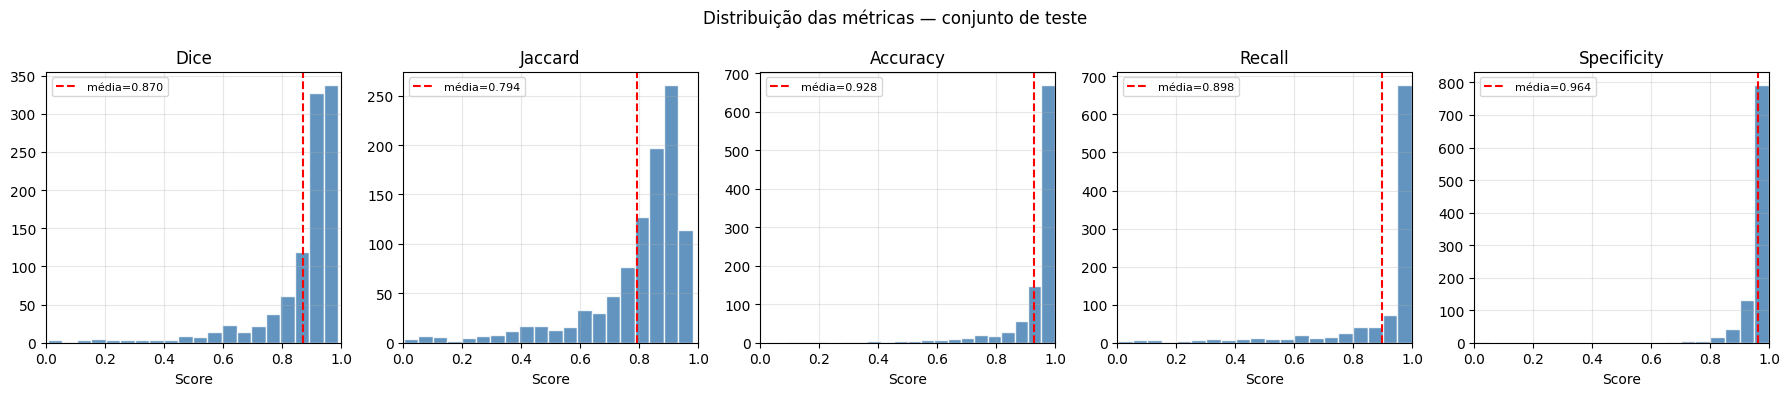


10 piores casos (menor Dice):


,image_idx,dice,jaccard,accuracy,precision,recall,specificity
890,890,0.0051,0.0026,0.9704,0.0495,0.0027,0.9985
680,680,0.0195,0.0098,0.6055,0.4804,0.0099,0.9930
668,668,0.0264,0.0134,0.7364,1.0000,0.0134,1.0000
596,596,0.0784,0.0408,0.1624,1.0000,0.0408,1.0000
675,675,0.1116,0.0591,0.1089,1.0000,0.0591,1.0000
592,592,0.1281,0.0685,0.6671,0.9975,0.0685,0.9999
761,761,0.1406,0.0756,0.6938,0.0880,0.3503,0.7203
887,887,0.1622,0.0883,0.0924,1.0000,0.0883,1.0000
552,552,0.1628,0.0886,0.3351,1.0000,0.0886,1.0000
673,673,0.1680,0.0917,0.0917,1.0000,0.0917,1.0000


In [7]:
metrics_to_plot = ['dice', 'jaccard', 'accuracy', 'recall', 'specificity']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))
fig.suptitle('Distribuição das métricas — conjunto de teste', fontsize=12)

for ax, metric in zip(axes, metrics_to_plot):
    ax.hist(df_test[metric], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df_test[metric].mean(), color='red', linestyle='--',
               label=f'média={df_test[metric].mean():.3f}')
    ax.set_title(metric.capitalize())
    ax.set_xlabel('Score')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('skin_lesion/results/figures/test_metrics_distribution_5blocks.png', dpi=150)
plt.show()

# Piores casos — útil para análise de erro
print('\n10 piores casos (menor Dice):')
display(df_test.nsmallest(10, 'dice'))
